# Week 5 In-Class Exercise: Naive Bayes Text Classification

In the demonstration, we saw **Naive Bayes** classify newsgroup posts: a fast, *generative* classifier built on Bayes' rule and a conditional-independence assumption, and the classic baseline for **text classification**.

In this exercise, you'll build the same kind of classifier yourself, then explore how the choices you make — the text representation, the NB variant, and the smoothing parameter — change the result.

> **Dataset: 20 Newsgroups.** Public Usenet posts. To keep things fast and focused, we'll use four benign topics: `comp.graphics`, `rec.autos`, `rec.sport.baseball`, and `sci.space`. Your classifier predicts which newsgroup a post came from.

You'll adapt the techniques from the demo, not invent new ones.

1. Load the text data
2. Turn documents into features with a **vectorizer**
3. Train a **Multinomial Naive Bayes** classifier and measure accuracy
4. Compare **CountVectorizer** vs **TF-IDF**
5. Analyze errors with a **confusion matrix**
6. Tune the **`alpha`** smoothing parameter
7. Classify **your own** sentences

### Useful API References

| Task | Documentation |
|------|---------------|
| Load text data | [fetch_20newsgroups](https://scikit-learn.org/stable/modules/generated/sklearn.datasets.fetch_20newsgroups.html) |
| Word counts | [CountVectorizer](https://scikit-learn.org/stable/modules/generated/sklearn.feature_extraction.text.CountVectorizer.html) |
| TF-IDF | [TfidfVectorizer](https://scikit-learn.org/stable/modules/generated/sklearn.feature_extraction.text.TfidfVectorizer.html) |
| Multinomial NB | [MultinomialNB](https://scikit-learn.org/stable/modules/generated/sklearn.naive_bayes.MultinomialNB.html) |
| Complement NB | [ComplementNB](https://scikit-learn.org/stable/modules/generated/sklearn.naive_bayes.ComplementNB.html) |
| Pipelines | [make_pipeline](https://scikit-learn.org/stable/modules/generated/sklearn.pipeline.make_pipeline.html) |
| Accuracy / report | [accuracy_score](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.accuracy_score.html), [classification_report](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.classification_report.html) |
| Confusion matrix | [ConfusionMatrixDisplay](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.ConfusionMatrixDisplay.html) |

<table align="left">
  <td>
    <a href="https://colab.research.google.com/github/pjmcswee/IST707-Notebooks/blob/main/week5/week5_naive_bayes_inclass_exercise.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>
  </td>
</table>

## Setup

In [25]:
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

plt.rc('font', size=13)
plt.rc('axes', labelsize=13, titlesize=13)
plt.rc('legend', fontsize=11)

## Step 1: Load the Data (Provided)

We fetch the train and test splits and strip headers/footers/quotes so the model learns from the message content, not metadata. This cell is provided — just run it. (The first run downloads ~14 MB.)

In [26]:
from sklearn.datasets import fetch_20newsgroups

categories = ['comp.graphics', 'rec.autos', 'rec.sport.baseball', 'sci.space']
remove = ('headers', 'footers', 'quotes')

train = fetch_20newsgroups(subset='train', categories=categories,
                           remove=remove, random_state=42)
test = fetch_20newsgroups(subset='test', categories=categories,
                          remove=remove, random_state=42)

print('Training documents:', len(train.data))
print('Test documents:    ', len(test.data))
print('Classes:', train.target_names)
print('\n--- Example document ---')
print('LABEL:', train.target_names[train.target[0]])
print(train.data[0][:300])

Training documents: 2368
Test documents:     1576
Classes: ['comp.graphics', 'rec.autos', 'rec.sport.baseball', 'sci.space']

--- Example document ---
LABEL: rec.sport.baseball


What makes you think Buck will still be in New York at year's end with
George back?  :-)

--
    Keith Keller				LET'S GO RANGERS!!!!!
						LET'S GO QUAKERS!!!!!
	kkeller@mail.sas.upenn.edu		IVY LEAGUE CHAMPS!!!!


## Step 2: Turn Text into Features

A classifier needs numbers, not strings. `CountVectorizer` builds a "bag of words": each document becomes a vector of word counts.

**Your turn!** Fit a `CountVectorizer(stop_words='english')` on the training text and report the shape of the resulting document-term matrix and the vocabulary size.

**Hint (from the demo):**
```python
from sklearn.feature_extraction.text import CountVectorizer
vectorizer = CountVectorizer(stop_words='english')
X_train_counts = vectorizer.fit_transform(train.data)
X_train_counts.shape
```

In [27]:
from sklearn.feature_extraction.text import CountVectorizer

# TODO: Fit a CountVectorizer on train.data. Print the document-term matrix
#       shape and the vocabulary size.
# Your code here:

vectorizer = CountVectorizer(stop_words='english')

X_train_counts = vectorizer.fit_transform(train.data)

print('Document-term matrix shape:', X_train_counts.shape)
print('Vocabulary size:', len(vectorizer.vocabulary_))


Document-term matrix shape: (2368, 25455)
Vocabulary size: 25455


**Question:** The document-term matrix has thousands of columns (one per vocabulary word) but each individual post only uses a few dozen words. What does that tell you about the matrix — is it mostly full or mostly empty? Why is that a good match for Naive Bayes rather than a problem?

*Your answer:* The fact that the matrix has thousands of columns, one for each word, but each post only used a few dozen words tells us that the matrix is sparse, so it is mostly empty. This is a good match for Naive Bayes because it drastically saves memory and speeds up training by only storing and processing non-zero values, which is ideal for text data where most words do not appear in most documents. 



## Step 3: Train Multinomial Naive Bayes

`MultinomialNB` is the NB variant built for count data. Bundle the vectorizer and classifier in a `Pipeline` so the same transformation applies to train and test.

**Your turn!** Build and fit a `make_pipeline(CountVectorizer(stop_words='english'), MultinomialNB())`, then print the **test accuracy**.

**Hint (from the demo):**
```python
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import make_pipeline
from sklearn.metrics import accuracy_score
nb_clf = make_pipeline(CountVectorizer(stop_words='english'), MultinomialNB())
nb_clf.fit(train.data, train.target)
```

In [28]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import make_pipeline
from sklearn.metrics import accuracy_score

# TODO: Build the pipeline, fit on the training data, and print test accuracy.
# Your code here:

nb_clf  = make_pipeline(CountVectorizer(stop_words = 'english'), MultinomialNB())
nb_clf.fit(train.data, train.target)

nb_preds = nb_clf.predict(test.data)

print(accuracy_score(test.target, nb_preds))



0.8902284263959391


**Question:** This is a 4-class problem. What accuracy would a classifier get by always guessing the same single class (roughly)? How does your Naive Bayes accuracy compare?

*Your answer:* Since this is a four class problem if we *assume* that each of the 4 classes appears an equal amount of times in the data, a classifier that guesses the same single class each time would have an accuracy of ~25%. The Naive Bayes I just trained has an accuracy of 89% which is significantly better than a classifier that guesses the same class for every prediction.



## Step 4: CountVectorizer vs TF-IDF

Raw counts over-reward common words. **TF-IDF** re-weights each word by how *informative* it is (rare, topic-specific words count more).

**Your turn!** Build a second pipeline using `TfidfVectorizer(stop_words='english')` instead of `CountVectorizer`, and print its test accuracy next to the CountVectorizer one from Step 3.

**Hint (from the demo):**
```python
from sklearn.feature_extraction.text import TfidfVectorizer
tfidf_clf = make_pipeline(TfidfVectorizer(stop_words='english'), MultinomialNB())
```

In [29]:
from sklearn.feature_extraction.text import TfidfVectorizer

# TODO: Build a TF-IDF + MultinomialNB pipeline; print its test accuracy
#       alongside the CountVectorizer result.
# Your code here:

tfidf_clf = make_pipeline(TfidfVectorizer(stop_words = 'english'), MultinomialNB())
tfidf_clf.fit(train.data, train.target)

tfidf_preds = tfidf_clf.predict(test.data)

print('CountVectorizer accuracy:', accuracy_score(test.target, nb_preds))
print('TF-IDF accuracy:        ', accuracy_score(test.target, tfidf_preds))



CountVectorizer accuracy: 0.8902284263959391
TF-IDF accuracy:         0.8972081218274112


**Question:** Did TF-IDF help, hurt, or make little difference here? Give one reason TF-IDF often improves a text classifier compared to raw counts.

*Your answer:* TF-IDF slightly helped, it increased the accuracy of the model by ~0.007. TF-IDF often improves a text classifier compared to raw counts because it gives a higher weight to rarer words, and a lower weight to more common words. Words that appear more frequently across all classes are rarely identifiers of a class, but words that appear rarely across the entire corpus, but often within classes are distinct signs that a document belongs to a specific class. This lets the more distinct words drive the prediction, rather than the filler words.



## Step 5: Error Analysis

**Your turn!** Using your TF-IDF classifier's predictions on the test set, display a **confusion matrix** (with `display_labels=train.target_names`) and print a `classification_report`.

**Hint (from the demo):**
```python
from sklearn.metrics import ConfusionMatrixDisplay, classification_report
ConfusionMatrixDisplay.from_predictions(test.target, y_pred,
                                        display_labels=train.target_names,
                                        xticks_rotation=45)
```

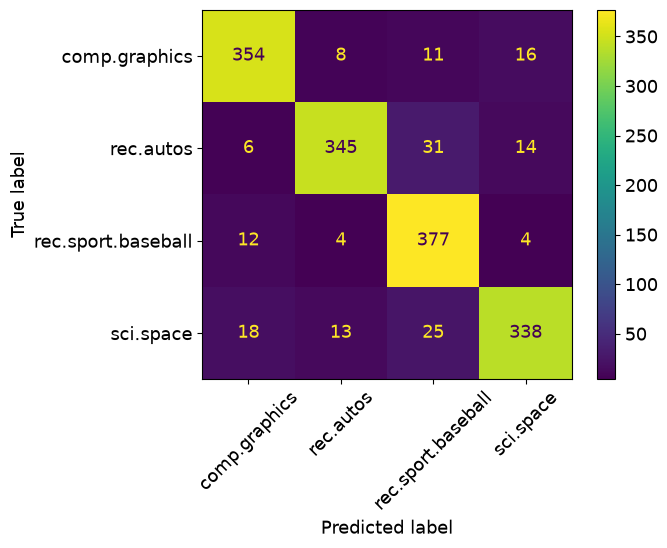

                    precision    recall  f1-score   support

     comp.graphics       0.91      0.91      0.91       389
         rec.autos       0.93      0.87      0.90       396
rec.sport.baseball       0.85      0.95      0.90       397
         sci.space       0.91      0.86      0.88       394

          accuracy                           0.90      1576
         macro avg       0.90      0.90      0.90      1576
      weighted avg       0.90      0.90      0.90      1576



In [30]:
from sklearn.metrics import ConfusionMatrixDisplay, classification_report

# TODO: Display the confusion matrix and print the classification report
#       for your TF-IDF classifier.
# Your code here:


ConfusionMatrixDisplay.from_predictions(test.target, tfidf_preds,
                                        display_labels=train.target_names,
                                        xticks_rotation=45)
plt.show()

print(classification_report(test.target, tfidf_preds, target_names=train.target_names))


**Question:** Which two newsgroups get confused most often? Suggest a reason based on the *vocabulary* those topics might share.

*Your answer:* The two newsgroups that get most commonly confused are rec.autos documents are being predicted to be rec.sport.baseball documents; and sci.space are being predicted to be rec.sport.baseball documents. If I had to guess, these categories are getting confused because each topic talks about averages, records, years, scores etc. and most likely mentions words like: run, drive, pitch, launch, record, season, fast, speed, etc.



## Step 6: Tune the Smoothing Parameter `alpha`

Naive Bayes multiplies per-word probabilities; a word unseen in a class would give probability 0 and wipe out the whole product. **Additive smoothing** adds `alpha` to every count to prevent that. `alpha=1.0` is the default.

**Your turn!** Loop over `alpha` in `[0.001, 0.01, 0.1, 1.0, 10.0]` for a TF-IDF + `MultinomialNB(alpha=...)` pipeline and print the test accuracy for each. Which `alpha` is best?

**Hint (from the demo):**
```python
for alpha in [0.001, 0.01, 0.1, 1.0, 10.0]:
    model = make_pipeline(TfidfVectorizer(stop_words='english'),
                          MultinomialNB(alpha=alpha))
```

In [31]:
# TODO: Sweep alpha and print test accuracy for each value.
# Your code here:

for alpha in [0.001, 0.01, 0.1, 1.0, 10.0]:
    model = make_pipeline(
        TfidfVectorizer(stop_words = 'english'),
        MultinomialNB(alpha = alpha)
    )

    model.fit(train.data, train.target)

    print(f'Accuracy for alpha of {alpha}: {accuracy_score(test.target, model.predict(test.data)):.4f}')


Accuracy for alpha of 0.001: 0.8896
Accuracy for alpha of 0.01: 0.8953
Accuracy for alpha of 0.1: 0.9055
Accuracy for alpha of 1.0: 0.8972
Accuracy for alpha of 10.0: 0.8813


**Question:** What happens to accuracy when `alpha` is very small (like 0.001) versus very large (like 10)? Explain in terms of trusting rare words too much versus washing out real signal.

*Your answer:* In this case, the alpha of 0.1 performs the best. When alpha is very small like 0.001 the estimates are almost identical to the raw probabilities. If a rare word shows up one time in one class, its probability in that class is small but real and in every other class it's close to zero. That one rare occurrence will wash out the rest of the classes since the other classes will have a probability close to 0, the model is trusting the noise in the training data. 

On the other hand, if alpha is very large like 10, you're adding 10 fake occurrences of every word to every class. That swamps the real counts for most words and each classes probabilities are significantly altered becoming nearly identical. Words that actually separate the classes lose their edge, because every class now looks like every other class.

## Step 7: Classify Your Own Sentences

**Your turn!** Write **four** short sentences of your own — one clearly about each topic (computer graphics, cars, baseball, space) — put them in a list, and have your best classifier predict the topic of each. Print each sentence next to its predicted label.

**Hint:** The pipeline predicts directly from raw strings: `best_clf.predict(my_sentences)` returns label indices; map them through `train.target_names`.

In [32]:
import random

# TODO: Create a list of 4 sentences (one per topic) and print each with its
#       predicted newsgroup label.
# Your code here:

sample_sentences = [
    'This new 3D software lets me render highly realistic models!',
    'BMW is getting ready to release its new line of M cars, they are the fastest ones yet.',
    'The Yankees scored three runs in the bottom of the ninth when the shortstop hit a double off the left field wall.',
    'NASA launched the new satellite into low Earth orbit, where it will study the atmosphere for the next five years.'
]

random.shuffle(sample_sentences)

best_clf = make_pipeline(
        TfidfVectorizer(stop_words = 'english'),
        MultinomialNB(alpha = 0.1)
    )

best_clf.fit(train.data, train.target)

preds = best_clf.predict(sample_sentences)

for i in range(len(sample_sentences)):
    print(f'Sample Sentence:\n{sample_sentences[i]}')
    print(f'Predicted Class: {train.target_names[preds[i]]}')
    print(' ')


Sample Sentence:
This new 3D software lets me render highly realistic models!
Predicted Class: comp.graphics
 
Sample Sentence:
The Yankees scored three runs in the bottom of the ninth when the shortstop hit a double off the left field wall.
Predicted Class: rec.sport.baseball
 
Sample Sentence:
BMW is getting ready to release its new line of M cars, they are the fastest ones yet.
Predicted Class: rec.autos
 
Sample Sentence:
NASA launched the new satellite into low Earth orbit, where it will study the atmosphere for the next five years.
Predicted Class: sci.space
 


**Question:** Did the classifier get all four of your sentences right? If any were wrong (or you could imagine one being wrong), what about the sentence's wording might have thrown it off?

*Your answer:* The classifier got all four of my sentences correct on the first try! I could imagine that if I had words in my sample sentances like "speed" and "launch" in the space or cars sentance, it might've been misclassified as a baseball sentance like I mentioned in the analysis of the confusion matrix.



## Reflection Questions

Answer each question in the cell below it (1-3 sentences each).

**Q1:** Naive Bayes assumes words are *independent given the class*. Give an example of two words whose appearances are clearly **not** independent in real text. Why does the classifier still work well despite this false assumption?

*Your answer:* Two words that appear next to each other frequently that are not independent in real text are 'home' and 'run', and 'space' and 'shuttle'. The classifier still works well despite this false assumption because Naive Bayes just has to get the ranking of the classes right. The prediction is just whichever class scores the highest. Two correlated words get counted as two separate pieces of evidence when they're actually one, so the evidence is double counted. The double-counted evidence will likely point towards the correct class, so the model still works despite the false assumption.



**Q2:** This week's other topic was SVMs. Naive Bayes trains almost instantly and needs little data; an SVM with an RBF kernel is slower. Name one situation where you'd reach for Naive Bayes first, and one where an SVM might be worth the extra cost.

*Your answer:* I'd reach for the Naive Bayes model first on text classification with a large vocabulary and limited labeled data, or when I need a fast baseline such as for spam filtering, since it trains almost instantly and performs well in high dimensions. I'd reach for an SVM with an RBF kernel when I have a moderately sized dataset with class boundaries that are non-linear, so the features interact in ways a linear model or Naive Bayes can't capture.



**Q3:** We used `MultinomialNB` for word counts. Why would `GaussianNB` be the wrong choice for this bag-of-words data, and what kind of data *is* `GaussianNB` designed for?

*Your answer:* GaussianNB assumes that each feature follows a bell curve within each class, but word counts are non-negative numbers, consisting of mostly zeros, with a long tail of a few high counts, so a normal distribution fits them poorly. MultinomialNB instead models how often each word appears out of a document's total words, which is exactly what a bag of words is. GaussianNB is designed for continuous numeric features that are roughly normally distributed within each class. 



**Q4:** We stripped the headers, footers, and quoted text from the posts. How do you think accuracy would change if we left them in, and would that be a fair measure of the classifier's real ability to understand the message content?

*Your answer:* I think if we left the headers, footers, and quoted text in the posts, the accuracy would have gone up. That being said I don't think it is a fair measure of the classifier's real ability to understand the message content, because the headers and footers likely included metadata giving away what category the post belonged in, which the NB model would end up using to make its prediction rather than looking at the contents of the post and making a prediction.

